# A7: ML — Food Group Classification & Nutritional Quality Prediction

**Inputs:** foundation_analysis_ready.csv (A1), foundation_topsis_ranking.csv (A6)

**Output:** foundation_ml_results.csv

## Methodology

This notebook applies supervised machine learning to the Foundation Foods dataset along two complementary tracks:

### Track D — Food Group Classification from Nutrients Alone
Can a model correctly identify a food's category (meat, dairy, vegetables, etc.) using only its nutrient density profile — no names, no metadata? If yes, nutrients encode enough information to replicate human food taxonomy. More interestingly, foods the model *misclassifies* are nutritional outliers: they violate the typical nutrient correlations of their group.

Pipeline: StandardScaler → Random Forest + XGBoost, stratified 5-fold CV evaluated with **out-of-fold predictions** (unbiased), SHAP TreeExplainer for global and per-class feature importance.

### Track A — Nutritional Quality Score Prediction (TOPSIS regression)
Predict each food's TOPSIS score (A6) from its raw nutrient profile. SHAP reveals which nutrients drive overall nutritional quality in a nonlinear, interaction-aware way.

**Note on circularity:** TOPSIS is a deterministic function of the same nutrient columns used as features. The regression is an *attribution* exercise, not held-out forecasting — the R² will be high by construction. The value is the SHAP decomposition.

### Evaluation philosophy
All metrics (confusion matrix, per-class accuracy, classification report) are computed from **out-of-fold cross-validation predictions** via `cross_val_predict` — each sample is predicted by a model that never saw it during training. The full-data fit is used exclusively for SHAP (TreeExplainer requires a single fitted model).

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import (
    StratifiedKFold, KFold,
    cross_val_score, cross_val_predict,
    learning_curve,
)
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    r2_score, mean_absolute_error,
)
import xgboost as xgb
import shap

In [2]:
PALETTE = {
    "meat_fish_eggs":     "#e74c3c",
    "fruits_veg_legumes": "#2ecc71",
    "cereals":            "#f39c12",
    "dairy":              "#3498db",
    "fats":               "#9b59b6",
    "condiments":         "#1abc9c",
    "beverages":          "#34495e",
    "sweets":             "#e91e63",
    "default":            "#95a5a6",
}

AGRIBALYSE_GROUP_LABELS = {
    "viandes, \u0153ufs, poissons":                          "meat_fish_eggs",
    "fruits, l\u00e9gumes, l\u00e9gumineuses et ol\u00e9agineux": "fruits_veg_legumes",
    "produits c\u00e9r\u00e9aliers":                               "cereals",
    "entr\u00e9es et plats compos\u00e9s":                         "prepared_meals",
    "lait et produits laitiers":                         "dairy",
    "aides culinaires et ingr\u00e9dients divers":            "condiments",
    "boissons":                                          "beverages",
    "mati\u00e8res grasses":                                  "fats",
    "produits sucr\u00e9s":                                   "sweets",
    "aliments infantiles":                               "infant",
    "glaces et sorbets":                                 "ice_cream",
}

CV_FOLDS = 5
RANDOM_SEED = 42

## 1. Load & Merge Data

In [3]:
df_base = pd.read_csv("foundation_analysis_ready.csv")
df_base["group_en"] = df_base["co2_group"].map(AGRIBALYSE_GROUP_LABELS).fillna("other")

df_topsis = pd.read_csv("foundation_topsis_ranking.csv")[["description", "topsis_score"]]
df = df_base.merge(df_topsis, on="description", how="left")

density_cols = [c for c in df.columns if c.endswith("_per_100kcal")]

print(f"Total foods: {len(df)}")
print(f"Nutrient density features: {len(density_cols)}")
print(f"Foods with TOPSIS score: {df['topsis_score'].notna().sum()}")
print(f"\nFood group distribution:")
print(df["group_en"].value_counts())

Total foods: 357
Nutrient density features: 20
Foods with TOPSIS score: 357

Food group distribution:
group_en
fruits_veg_legumes    157
meat_fish_eggs         87
cereals                44
dairy                  29
fats                   12
condiments             11
beverages               9
prepared_meals          5
sweets                  3
Name: count, dtype: int64


## 2. Feature Matrix & Label Encoding

Groups with fewer than 10 samples are dropped — too few for reliable stratified CV.

In [4]:
MIN_GROUP_SIZE = 10

group_counts  = df["group_en"].value_counts()
valid_groups  = group_counts[group_counts >= MIN_GROUP_SIZE].index.tolist()
dropped       = group_counts[group_counts < MIN_GROUP_SIZE].index.tolist()

print(f"Keeping {len(valid_groups)} groups (n >= {MIN_GROUP_SIZE}):")
for g in valid_groups:
    print(f"  {g}: {group_counts[g]}")
print(f"\nDropped: {dropped}")

df_clf = df[df["group_en"].isin(valid_groups)].copy()
df_clf = df_clf.dropna(subset=density_cols).reset_index(drop=True)

le = LabelEncoder()
y_clf = le.fit_transform(df_clf["group_en"])
class_names = le.classes_

scaler = StandardScaler()
X_clf  = scaler.fit_transform(df_clf[density_cols])

short_names = [
    c.replace("_per_100kcal", "")
     .replace("_", " ")
     .replace("Fatty acids total ", "FA ")
     .replace("Vitamin ", "Vit ")
     .replace("total ascorbic acid", "")
     .strip()
    for c in density_cols
]

print(f"\nClassification dataset: {len(df_clf)} foods, {len(valid_groups)} groups")
print(f"Feature matrix: {X_clf.shape}")
print(f"Classes: {list(class_names)}")

Keeping 6 groups (n >= 10):
  fruits_veg_legumes: 157
  meat_fish_eggs: 87
  cereals: 44
  dairy: 29
  fats: 12
  condiments: 11

Dropped: ['beverages', 'prepared_meals', 'sweets']

Classification dataset: 340 foods, 6 groups
Feature matrix: (340, 20)
Classes: ['cereals', 'condiments', 'dairy', 'fats', 'fruits_veg_legumes', 'meat_fish_eggs']


## 3. Baseline

In [5]:
majority_class = df_clf["group_en"].value_counts().idxmax()
majority_frac  = df_clf["group_en"].value_counts(normalize=True).max()

print(f"Majority class: '{majority_class}' ({majority_frac*100:.1f}% of data)")
print(f"Baseline accuracy: {majority_frac*100:.1f}%")
print(f"Baseline macro-F1: ~{majority_frac / len(valid_groups):.3f}")

Majority class: 'fruits_veg_legumes' (46.2% of data)
Baseline accuracy: 46.2%
Baseline macro-F1: ~0.077


## 4. Track D — Cross-Validated Classification

### Model training & CV scoring
Both models are evaluated with stratified 5-fold CV (macro F1).
`n_jobs=1` avoids multiprocessing pickling issues on Windows.

In [6]:
CV_strat = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_SEED)

rf_clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=RANDOM_SEED,
    n_jobs=1,
)
rf_scores = cross_val_score(rf_clf, X_clf, y_clf, cv=CV_strat, scoring="f1_macro")
print(f"Random Forest  — macro F1: {rf_scores.mean():.3f} ± {rf_scores.std():.3f}")
print(f"  Per-fold: {[round(s,3) for s in rf_scores]}")

xgb_clf = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="mlogloss",
    random_state=RANDOM_SEED,
    n_jobs=1,
)
xgb_scores = cross_val_score(xgb_clf, X_clf, y_clf, cv=CV_strat, scoring="f1_macro")
print(f"XGBoost        — macro F1: {xgb_scores.mean():.3f} ± {xgb_scores.std():.3f}")
print(f"  Per-fold: {[round(s,3) for s in xgb_scores]}")
print(f"\nBaseline macro-F1: ~{majority_frac / len(valid_groups):.3f}")

Random Forest  — macro F1: 0.786 ± 0.017
  Per-fold: [np.float64(0.816), np.float64(0.773), np.float64(0.786), np.float64(0.783), np.float64(0.77)]
XGBoost        — macro F1: 0.754 ± 0.099
  Per-fold: [np.float64(0.688), np.float64(0.924), np.float64(0.771), np.float64(0.63), np.float64(0.758)]

Baseline macro-F1: ~0.077


### Out-of-fold predictions — unbiased confusion matrix & classification report

`cross_val_predict` returns a prediction for every sample from the fold where
that sample was held out — so the model never saw it during training.
**All evaluation metrics below use these OOF predictions, not the full-data fit.**

In [7]:
print("Generating out-of-fold predictions (Random Forest)...")
y_oof_rf = cross_val_predict(rf_clf, X_clf, y_clf, cv=CV_strat)

print("Generating out-of-fold predictions (XGBoost)...")
y_oof_xgb = cross_val_predict(xgb_clf, X_clf, y_clf, cv=CV_strat)

print("\n=== RANDOM FOREST — Out-of-fold classification report ===")
print(classification_report(y_clf, y_oof_rf, target_names=class_names))

print("\n=== XGBOOST — Out-of-fold classification report ===")
print(classification_report(y_clf, y_oof_xgb, target_names=class_names))

Generating out-of-fold predictions (Random Forest)...
Generating out-of-fold predictions (XGBoost)...

=== RANDOM FOREST — Out-of-fold classification report ===
                    precision    recall  f1-score   support

           cereals       0.90      0.86      0.88        44
        condiments       0.60      0.27      0.38        11
             dairy       0.78      0.86      0.82        29
              fats       0.91      0.83      0.87        12
fruits_veg_legumes       0.90      0.97      0.94       157
    meat_fish_eggs       0.91      0.86      0.89        87

          accuracy                           0.89       340
         macro avg       0.84      0.78      0.80       340
      weighted avg       0.89      0.89      0.89       340


=== XGBOOST — Out-of-fold classification report ===
                    precision    recall  f1-score   support

           cereals       0.84      0.84      0.84        44
        condiments       0.67      0.18      0.29        11
  

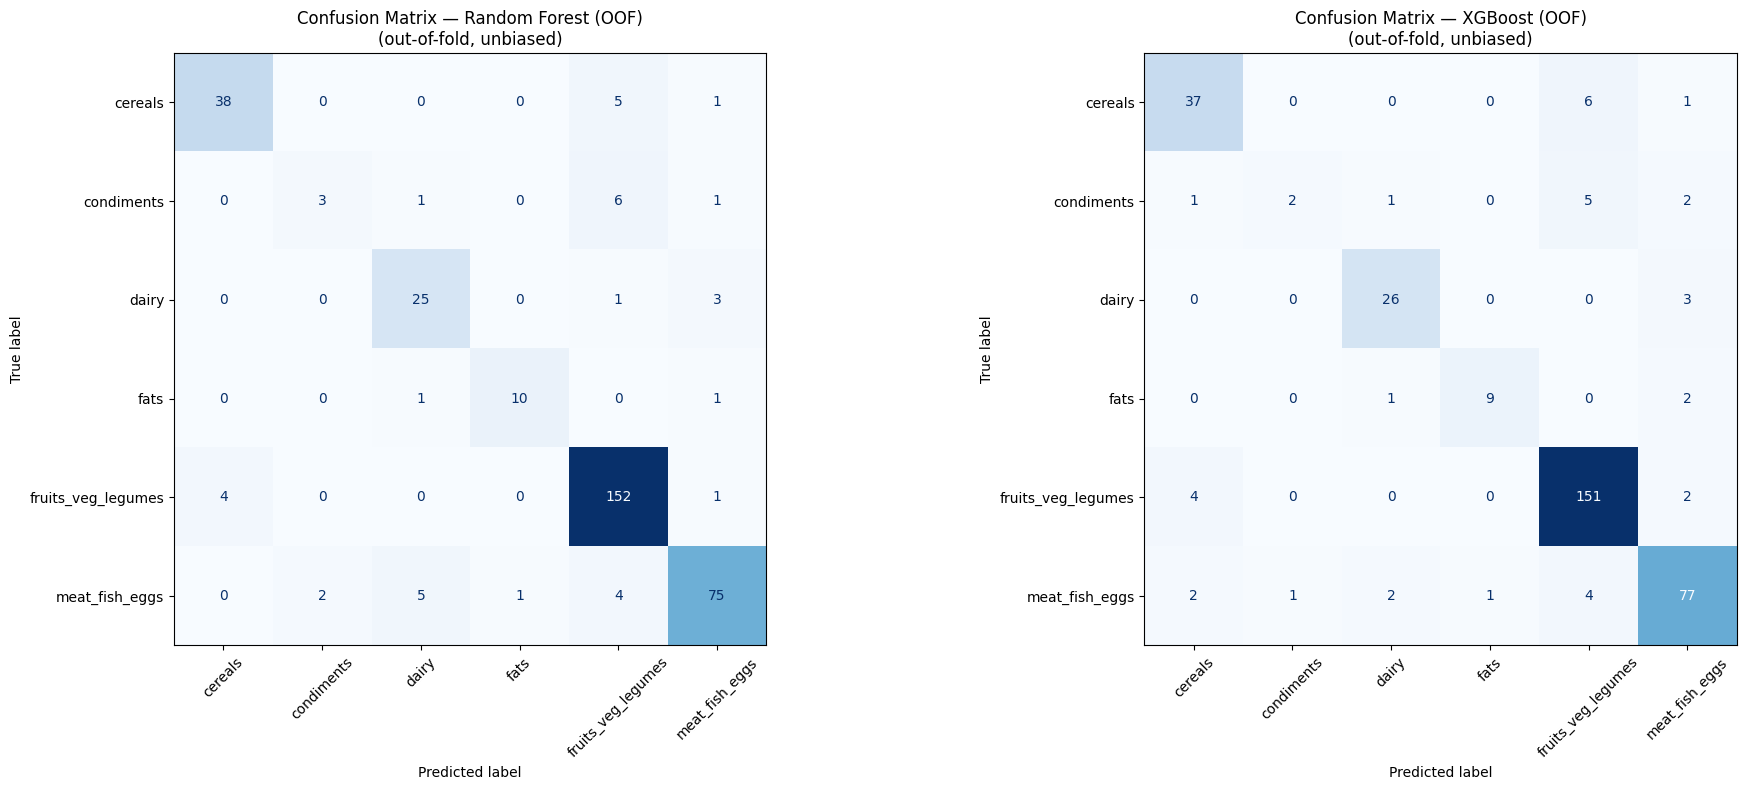

Per-class accuracy (Random Forest, OOF):
  cereals                  :  38/ 44  (86%)
  condiments               :   3/ 11  (27%)
  dairy                    :  25/ 29  (86%)
  fats                     :  10/ 12  (83%)
  fruits_veg_legumes       : 152/157  (97%)
  meat_fish_eggs           :  75/ 87  (86%)


In [8]:
# Confusion matrices side by side (OOF)
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

for ax, y_oof, title in zip(
    axes,
    [y_oof_rf, y_oof_xgb],
    ["Random Forest (OOF)", "XGBoost (OOF)"],
):
    cm_oof = confusion_matrix(y_clf, y_oof)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_oof, display_labels=class_names)
    disp.plot(ax=ax, colorbar=False, cmap="Blues", xticks_rotation=45)
    ax.set_title(f"Confusion Matrix — {title}\n(out-of-fold, unbiased)")

plt.tight_layout()
plt.savefig("A7_confusion_matrix_oof.png", dpi=150, bbox_inches="tight")
plt.show()

# Use RF OOF CM for downstream analysis
cm_oof = confusion_matrix(y_clf, y_oof_rf)

print("Per-class accuracy (Random Forest, OOF):")
for i, cls in enumerate(class_names):
    n_correct = cm_oof[i, i]
    n_total   = cm_oof[i].sum()
    print(f"  {cls:25s}: {n_correct:3d}/{n_total:3d}  ({100*n_correct/max(n_total,1):.0f}%)")

### Learning curves

Learning curves show how model performance scales with training set size.
A large gap between training and CV score = overfitting.
Converging curves = the model has learned the underlying structure.

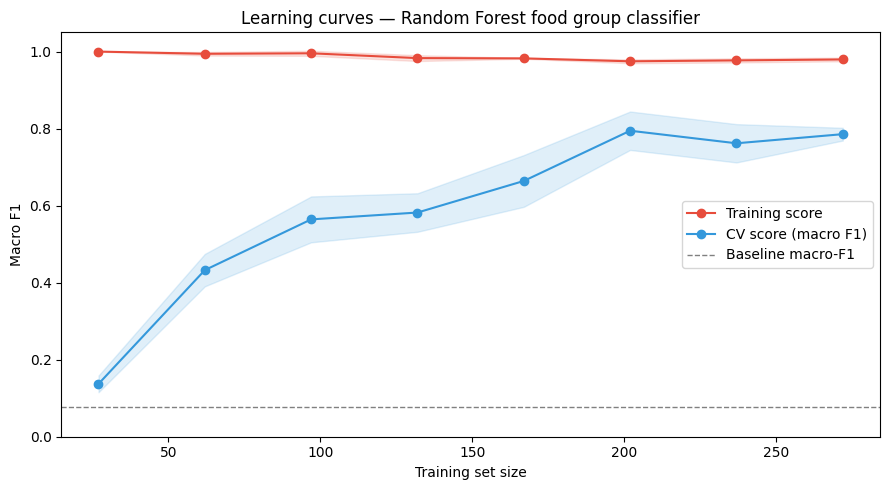

Final training score:  0.980 ± 0.005
Final CV score:        0.786 ± 0.017
Train-CV gap:          0.194  (some overfitting)


In [9]:
train_sizes, train_scores, cv_scores = learning_curve(
    rf_clf, X_clf, y_clf,
    cv=CV_strat,
    scoring="f1_macro",
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=1,
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
cv_mean    = cv_scores.mean(axis=1)
cv_std     = cv_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(train_sizes, train_mean, "o-", color="#e74c3c", label="Training score")
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                alpha=0.15, color="#e74c3c")
ax.plot(train_sizes, cv_mean, "o-", color="#3498db", label="CV score (macro F1)")
ax.fill_between(train_sizes, cv_mean - cv_std, cv_mean + cv_std,
                alpha=0.15, color="#3498db")
ax.axhline(majority_frac / len(valid_groups), ls="--", color="grey",
           lw=1, label="Baseline macro-F1")
ax.set_xlabel("Training set size")
ax.set_ylabel("Macro F1")
ax.set_title("Learning curves — Random Forest food group classifier")
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig("A7_learning_curve.png", dpi=150, bbox_inches="tight")
plt.show()

gap = train_mean[-1] - cv_mean[-1]
print(f"Final training score:  {train_mean[-1]:.3f} ± {train_std[-1]:.3f}")
print(f"Final CV score:        {cv_mean[-1]:.3f} ± {cv_std[-1]:.3f}")
print(f"Train-CV gap:          {gap:.3f}  ({'some overfitting' if gap > 0.1 else 'acceptable'})")

### OOF probability distribution

For each food, the model outputs a probability for its true class.
A well-calibrated model should be confident (high probability) when correct
and uncertain (low probability) when wrong.

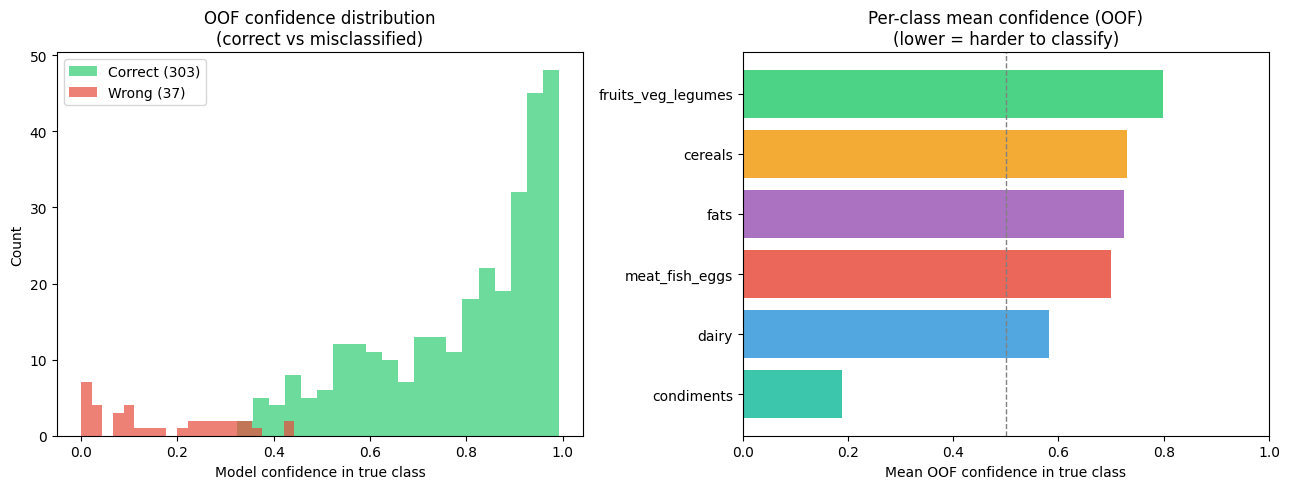

Overall mean OOF confidence: 0.724
Hardest class (lowest mean confidence): condiments (0.189)
Easiest class (highest mean confidence): fruits_veg_legumes (0.799)


In [10]:
# OOF probabilities
y_oof_proba = cross_val_predict(rf_clf, X_clf, y_clf, cv=CV_strat, method="predict_proba")
true_class_proba = np.array([y_oof_proba[i, y_clf[i]] for i in range(len(y_clf))])
correct_mask = y_oof_rf == y_clf

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: histogram of true-class probability, split correct vs wrong
axes[0].hist(true_class_proba[correct_mask],  bins=20, alpha=0.7,
             color="#2ecc71", label=f"Correct ({correct_mask.sum()})")
axes[0].hist(true_class_proba[~correct_mask], bins=20, alpha=0.7,
             color="#e74c3c", label=f"Wrong ({(~correct_mask).sum()})")
axes[0].set_xlabel("Model confidence in true class")
axes[0].set_ylabel("Count")
axes[0].set_title("OOF confidence distribution\n(correct vs misclassified)")
axes[0].legend()

# Right: per-class mean confidence (OOF)
per_class_conf = {}
for i, cls in enumerate(class_names):
    mask_cls = y_clf == i
    per_class_conf[cls] = true_class_proba[mask_cls].mean()

conf_series = pd.Series(per_class_conf).sort_values()
colors_bar = [PALETTE.get(c, PALETTE["default"]) for c in conf_series.index]
axes[1].barh(conf_series.index, conf_series.values, color=colors_bar, alpha=0.85)
axes[1].axvline(0.5, ls="--", color="grey", lw=1)
axes[1].set_xlabel("Mean OOF confidence in true class")
axes[1].set_title("Per-class mean confidence (OOF)\n(lower = harder to classify)")
axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.savefig("A7_oof_confidence.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Overall mean OOF confidence: {true_class_proba.mean():.3f}")
print(f"Hardest class (lowest mean confidence): {conf_series.idxmin()} ({conf_series.min():.3f})")
print(f"Easiest class (highest mean confidence): {conf_series.idxmax()} ({conf_series.max():.3f})")

### Confusion hotspots (OOF)

Which group pairs are most systematically confused?

Top confusion pairs (OOF — true → predicted):
              true          predicted  count
        condiments fruits_veg_legumes      6
           cereals fruits_veg_legumes      5
    meat_fish_eggs              dairy      5
fruits_veg_legumes            cereals      4
    meat_fish_eggs fruits_veg_legumes      4
             dairy     meat_fish_eggs      3
    meat_fish_eggs         condiments      2
             dairy fruits_veg_legumes      1
        condiments     meat_fish_eggs      1
           cereals     meat_fish_eggs      1
        condiments              dairy      1
fruits_veg_legumes     meat_fish_eggs      1


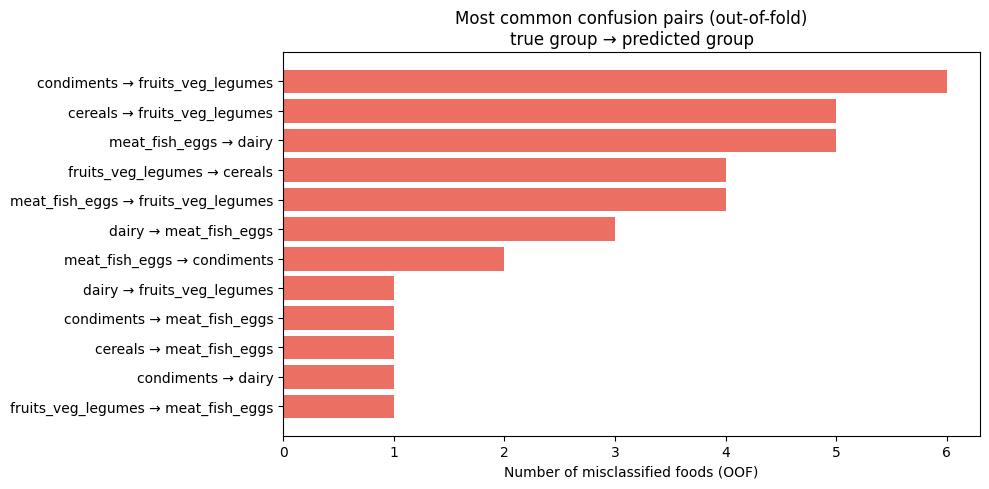

In [11]:
confusion_pairs = []
for i in range(len(class_names)):
    for j in range(len(class_names)):
        if i != j and cm_oof[i, j] > 0:
            confusion_pairs.append({
                "true":      class_names[i],
                "predicted": class_names[j],
                "count":     cm_oof[i, j],
            })

conf_df = (
    pd.DataFrame(confusion_pairs)
    .sort_values("count", ascending=False)
    .head(12)
    .reset_index(drop=True)
)

print("Top confusion pairs (OOF — true → predicted):")
print(conf_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
labels = [f"{r['true']} → {r['predicted']}" for _, r in conf_df.iterrows()]
ax.barh(labels[::-1], conf_df["count"][::-1], color="#e74c3c", alpha=0.8)
ax.set_xlabel("Number of misclassified foods (OOF)")
ax.set_title("Most common confusion pairs (out-of-fold)\ntrue group → predicted group")
plt.tight_layout()
plt.savefig("A7_confusion_hotspots.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. SHAP — What Nutrients Define Each Food Group?

Full-data fit used here — SHAP requires a single fitted model.
Results are clearly labelled as full-data SHAP, not OOF.

Computing SHAP values (TreeExplainer on Random Forest, full-data fit)...
SHAP array shape: (340, 20, 6)


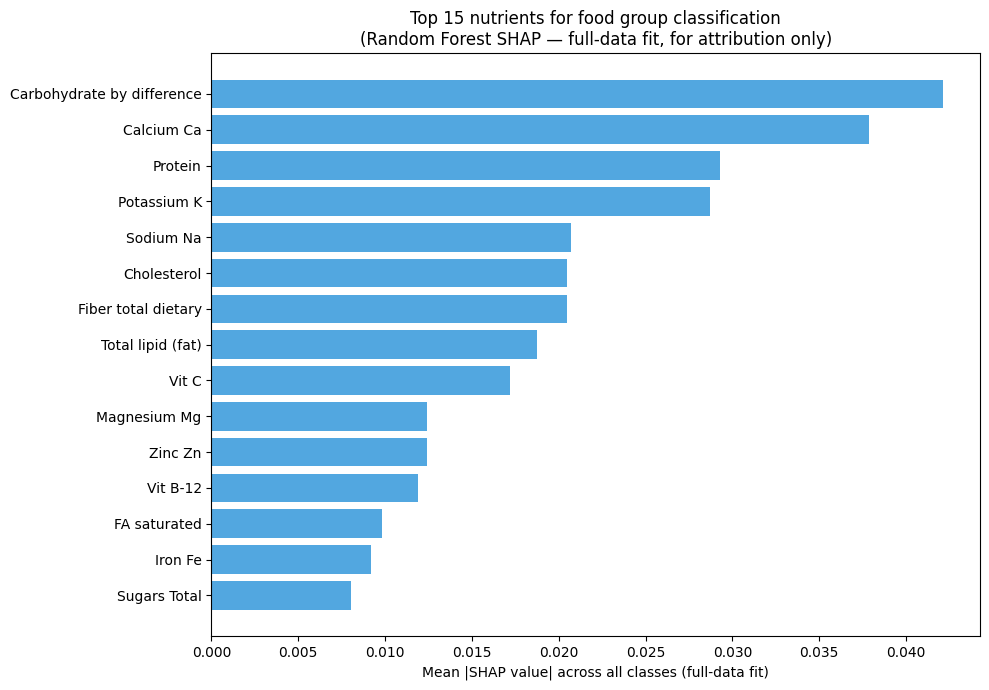


Top 10 most discriminative nutrients:
                   feature  mean_abs_shap
Carbohydrate by difference       0.042150
                Calcium Ca       0.037858
                   Protein       0.029268
               Potassium K       0.028691
                 Sodium Na       0.020720
               Cholesterol       0.020459
       Fiber total dietary       0.020458
         Total lipid (fat)       0.018722
                     Vit C       0.017178
              Magnesium Mg       0.012430


In [12]:
# Fit on full data for SHAP only
rf_clf.fit(X_clf, y_clf)
xgb_clf.fit(X_clf, y_clf)

print("Computing SHAP values (TreeExplainer on Random Forest, full-data fit)...")
explainer_clf   = shap.TreeExplainer(rf_clf)
shap_values_clf = explainer_clf.shap_values(X_clf)

if isinstance(shap_values_clf, list):
    shap_3d = np.stack(shap_values_clf, axis=2)
else:
    shap_3d = shap_values_clf

print(f"SHAP array shape: {shap_3d.shape}")

mean_abs_shap = np.abs(shap_3d).mean(axis=(0, 2))
importance_df = pd.DataFrame({
    "feature":       short_names,
    "mean_abs_shap": mean_abs_shap,
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 7))
top_n   = 15
top_imp = importance_df.head(top_n)
ax.barh(top_imp["feature"][::-1], top_imp["mean_abs_shap"][::-1],
        color="#3498db", alpha=0.85)
ax.set_xlabel("Mean |SHAP value| across all classes (full-data fit)")
ax.set_title(f"Top {top_n} nutrients for food group classification\n"
             "(Random Forest SHAP — full-data fit, for attribution only)")
plt.tight_layout()
plt.savefig("A7_shap_global_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nTop 10 most discriminative nutrients:")
print(importance_df.head(10)[["feature", "mean_abs_shap"]].to_string(index=False))

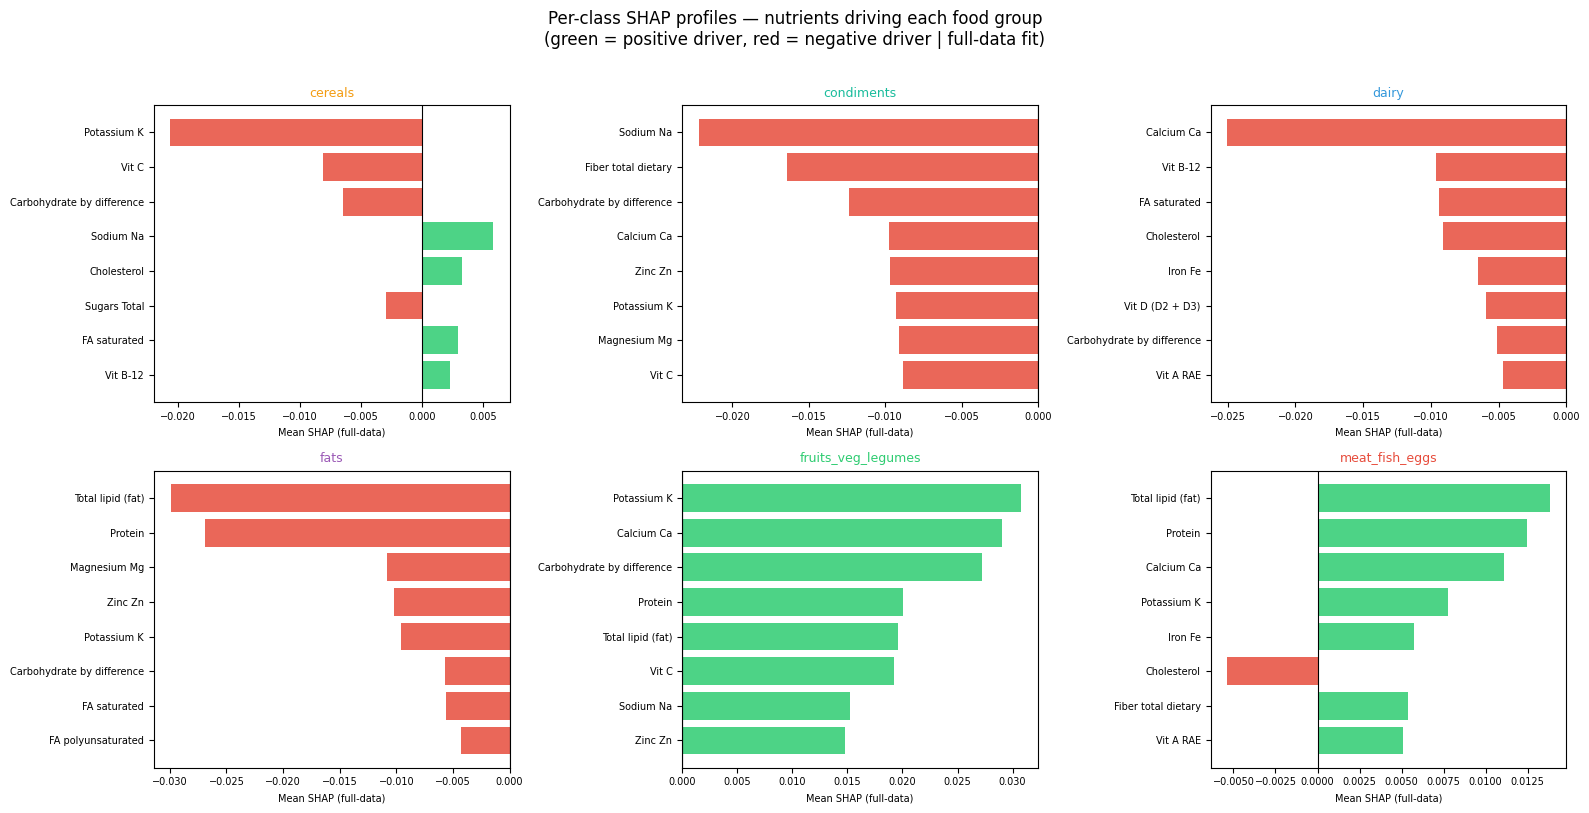

In [13]:
n_classes = len(class_names)
n_cols = 3
n_rows = (n_classes + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes_flat = axes.flat

for i, cls in enumerate(class_names):
    ax = axes_flat[i]
    class_shap  = shap_3d[:, :, i].mean(axis=0)
    idx_sorted  = np.argsort(np.abs(class_shap))[::-1][:8]
    feat_labels = [short_names[j] for j in idx_sorted]
    values      = [class_shap[j]  for j in idx_sorted]
    colors      = ["#2ecc71" if v > 0 else "#e74c3c" for v in values]
    ax.barh(feat_labels[::-1], values[::-1], color=colors[::-1], alpha=0.85)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(cls, fontsize=9, color=PALETTE.get(cls, PALETTE["default"]))
    ax.set_xlabel("Mean SHAP (full-data)", fontsize=7)
    ax.tick_params(labelsize=7)

for j in range(i + 1, n_rows * n_cols):
    axes_flat[j].set_visible(False)

plt.suptitle("Per-class SHAP profiles — nutrients driving each food group\n"
             "(green = positive driver, red = negative driver | full-data fit)", y=1.01)
plt.tight_layout()
plt.savefig("A7_shap_per_class.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Nutritional Outliers — Foods the Model Gets Wrong

We use OOF probabilities for outlier detection — methodologically correct
because confidence estimates come from models that never saw the food.

In [14]:
df_clf = df_clf.copy()
df_clf["predicted_group_oof"]  = le.inverse_transform(y_oof_rf)
df_clf["true_group_prob_oof"]  = true_class_proba
df_clf["predicted_group_prob"] = y_oof_proba.max(axis=1)
df_clf["correctly_classified"] = y_oof_rf == y_clf

outliers = (
    df_clf[~df_clf["correctly_classified"]]
    .sort_values("true_group_prob_oof")
    .head(25)
)

n_wrong = (~df_clf["correctly_classified"]).sum()
print(f"Misclassified (OOF): {n_wrong} / {len(df_clf)}  ({100*n_wrong/len(df_clf):.1f}%)")
print(f"\nTop 25 most surprising misclassifications (OOF):")
cols_out = ["description", "group_en", "predicted_group_oof",
            "true_group_prob_oof", "predicted_group_prob"]
print(outliers[cols_out].to_string(index=False))

Misclassified (OOF): 37 / 340  (10.9%)

Top 25 most surprising misclassifications (OOF):
                                           description           group_en predicted_group_oof  true_group_prob_oof  predicted_group_prob
                                   Buttermilk, low fat               fats               dairy             0.000000              0.715425
Turkey, ground, 93% lean, 7% fat, pan-broiled crumbles               fats      meat_fish_eggs             0.000000              0.974048
                                     Egg, whole, dried            cereals      meat_fish_eggs             0.003778              0.866120
                                           Garlic, raw         condiments  fruits_veg_legumes             0.009504              0.424915
                      Nuts, hazelnuts or filberts, raw     meat_fish_eggs  fruits_veg_legumes             0.015082              0.746983
                                         Collards, raw     meat_fish_eggs  fruits_veg_leg

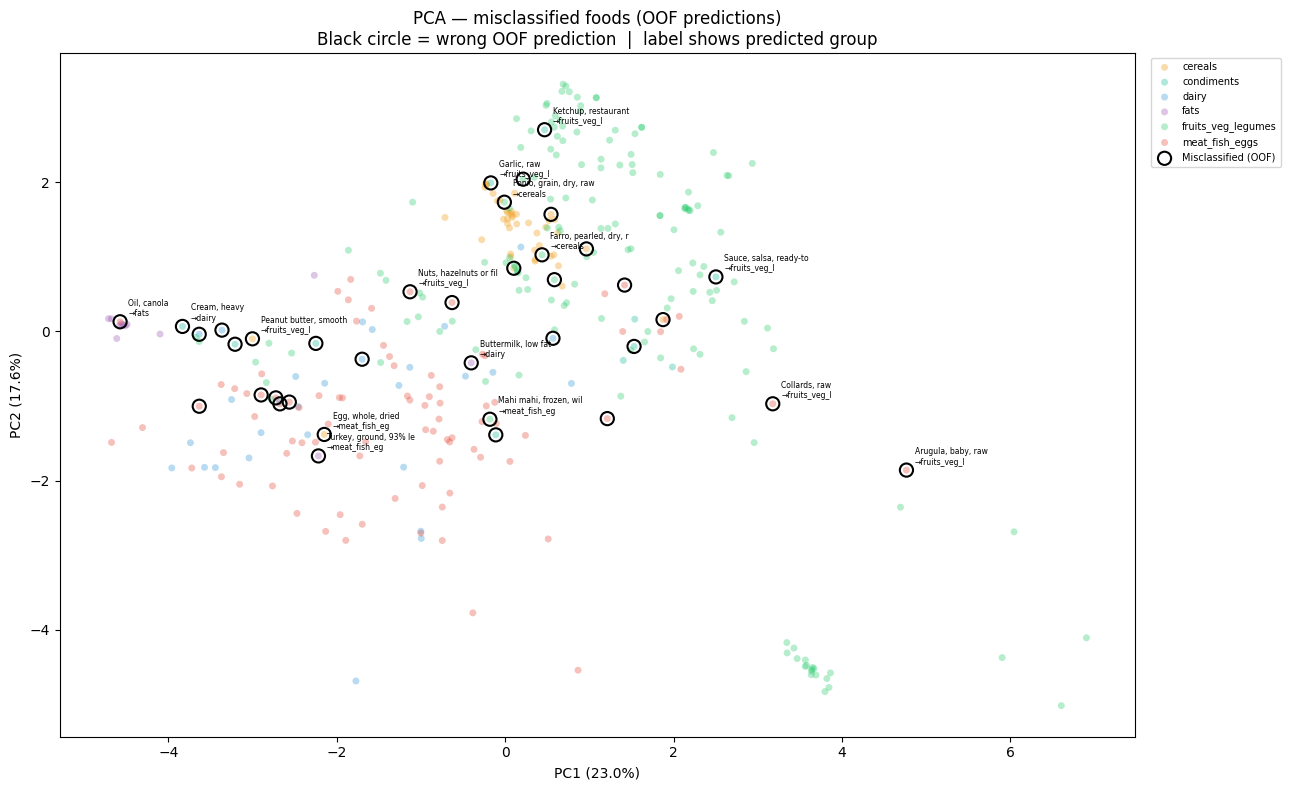

In [15]:
pca2 = PCA(n_components=2, random_state=RANDOM_SEED)
X_pca = pca2.fit_transform(X_clf)

df_clf["PCA1_ml"] = X_pca[:, 0]
df_clf["PCA2_ml"] = X_pca[:, 1]

outliers = (
    df_clf[~df_clf["correctly_classified"]]
    .sort_values("true_group_prob_oof")
    .head(25)
)

fig, ax = plt.subplots(figsize=(13, 8))
for grp, grp_df in df_clf.groupby("group_en"):
    ax.scatter(grp_df["PCA1_ml"], grp_df["PCA2_ml"],
               color=PALETTE.get(grp, PALETTE["default"]),
               alpha=0.35, s=25, edgecolors="none", label=grp)

mis = df_clf[~df_clf["correctly_classified"]]
ax.scatter(mis["PCA1_ml"], mis["PCA2_ml"],
           facecolors="none", edgecolors="black", s=90, linewidths=1.5,
           zorder=4, label="Misclassified (OOF)")

for _, r in outliers.head(15).iterrows():
    ax.annotate(
        f"{r['description'][:22]}\n→{r['predicted_group_oof'][:12]}",
        (r["PCA1_ml"], r["PCA2_ml"]),
        fontsize=5.5, xytext=(6, 4), textcoords="offset points", zorder=5,
    )

ax.set_xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_title("PCA — misclassified foods (OOF predictions)\n"
             "Black circle = wrong OOF prediction  |  label shows predicted group")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=7)
plt.tight_layout()
plt.savefig("A7_outliers_pca.png", dpi=150, bbox_inches="tight")
plt.show()

In [16]:
compare_cols = [
    "Protein_per_100kcal", "Total_lipid_(fat)_per_100kcal",
    "Carbohydrate_by_difference_per_100kcal", "Fiber_total_dietary_per_100kcal",
    "Fatty_acids_total_saturated_per_100kcal", "Calcium_Ca_per_100kcal",
    "Iron_Fe_per_100kcal", "Sodium_Na_per_100kcal",
]
compare_short = ["Protein", "Fat", "Carbs", "Fiber", "Sat.Fat", "Calcium", "Iron", "Sodium"]
compare_cols  = [c for c in compare_cols if c in df_clf.columns]
compare_short = compare_short[:len(compare_cols)]

print("=== Deep dive: 3 most nutritionally surprising misclassifications (OOF) ===\n")
for _, row in outliers.head(3).iterrows():
    true_grp  = row["group_en"]
    pred_grp  = row["predicted_group_oof"]
    true_mean = df_clf[df_clf["group_en"] == true_grp][compare_cols].mean()
    pred_mean = df_clf[df_clf["group_en"] == pred_grp][compare_cols].mean()
    food_vals = df_clf[df_clf["description"] == row["description"]][compare_cols]
    if food_vals.empty:
        continue
    food_vals = food_vals.iloc[0]

    print(f"Food:            {row['description']}")
    print(f"True group:      {true_grp}  (OOF confidence: {row['true_group_prob_oof']:.2%})")
    print(f"Predicted group: {pred_grp}  (OOF confidence: {row['predicted_group_prob']:.2%})")
    print(f"{'Nutrient':12s}  {'This food':>10s}  {'True grp avg':>13s}  {'Pred grp avg':>13s}")
    print("-" * 55)
    for col, short in zip(compare_cols, compare_short):
        print(f"{short:12s}  {food_vals[col]:>10.2f}  {true_mean[col]:>13.2f}  {pred_mean[col]:>13.2f}")
    print()

=== Deep dive: 3 most nutritionally surprising misclassifications (OOF) ===

Food:            Buttermilk, low fat
True group:      fats  (OOF confidence: 0.00%)
Predicted group: dairy  (OOF confidence: 71.54%)
Nutrient       This food   True grp avg   Pred grp avg
-------------------------------------------------------
Protein             8.09           1.70           7.01
Fat                 2.52          10.09           5.64
Carbs              11.23           0.94           5.25
Fiber               0.00           0.00           0.02
Sat.Fat             1.29           2.43           2.66
Calcium           280.38          24.94         268.44
Iron                0.03           0.06           0.24
Sodium            215.92          27.42         196.01

Food:            Turkey, ground, 93% lean, 7% fat, pan-broiled crumbles
True group:      fats  (OOF confidence: 0.00%)
Predicted group: meat_fish_eggs  (OOF confidence: 97.40%)
Nutrient       This food   True grp avg   Pred grp avg
------

## 7. Track A — TOPSIS Score Regression

5-fold CV with R² and MAE. OOF predictions used for residual analysis.
Full-data fit used for SHAP only.

In [17]:
df_reg = df.dropna(subset=["topsis_score"] + density_cols).copy().reset_index(drop=True)

scaler_reg = StandardScaler()
X_reg = scaler_reg.fit_transform(df_reg[density_cols])
y_reg = df_reg["topsis_score"].values

print(f"Regression dataset: {len(df_reg)} foods")
print(f"TOPSIS range: [{y_reg.min():.4f}, {y_reg.max():.4f}]  mean={y_reg.mean():.4f}")

Regression dataset: 357 foods
TOPSIS range: [0.3917, 0.5265]  mean=0.4368


In [18]:
CV_reg = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_SEED)

rf_reg = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    random_state=RANDOM_SEED,
    n_jobs=1,
)

r2_scores  = cross_val_score(rf_reg, X_reg, y_reg, cv=CV_reg, scoring="r2")
mae_scores = cross_val_score(rf_reg, X_reg, y_reg, cv=CV_reg,
                             scoring="neg_mean_absolute_error")

print("Random Forest Regressor (5-fold CV):")
print(f"  R²  : {r2_scores.mean():.3f} ± {r2_scores.std():.3f}")
print(f"  Per-fold R²: {[round(s,3) for s in r2_scores]}")
print(f"  MAE : {(-mae_scores).mean():.4f} ± {(-mae_scores).std():.4f}")
print()
print("Note: high R² expected — TOPSIS is a deterministic function of the same features.")
print("The value of this model is SHAP attribution, not held-out prediction accuracy.")

Random Forest Regressor (5-fold CV):
  R²  : 0.879 ± 0.031
  Per-fold R²: [np.float64(0.89), np.float64(0.926), np.float64(0.837), np.float64(0.855), np.float64(0.888)]
  MAE : 0.0059 ± 0.0005

Note: high R² expected — TOPSIS is a deterministic function of the same features.
The value of this model is SHAP attribution, not held-out prediction accuracy.


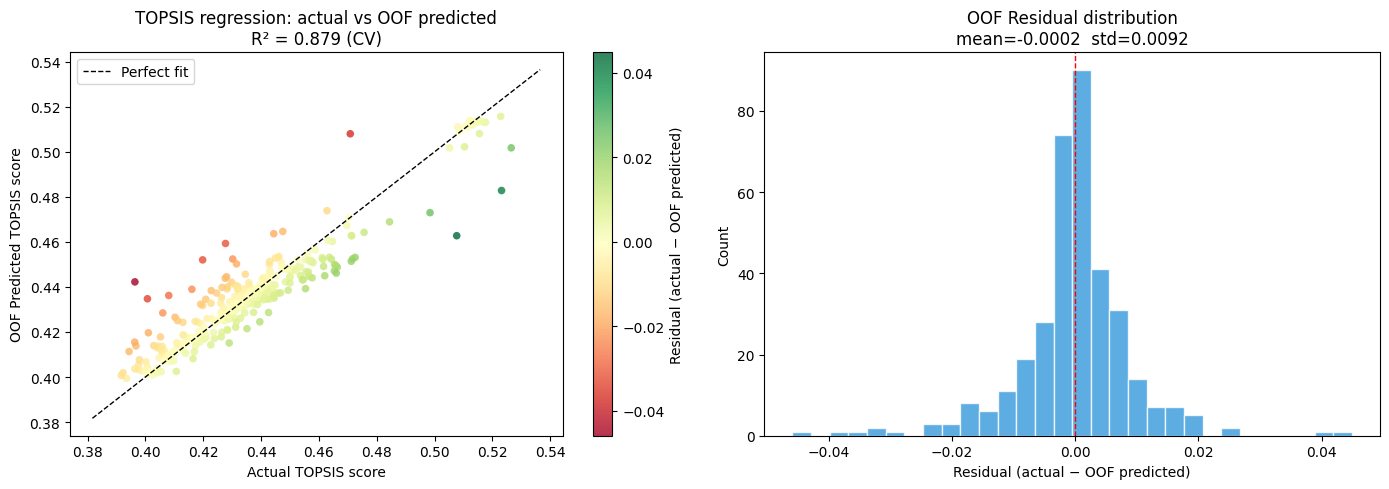

In [19]:
# OOF predictions for residual analysis
y_oof_reg = cross_val_predict(rf_reg, X_reg, y_reg, cv=CV_reg)

df_reg["topsis_predicted_oof"] = y_oof_reg
df_reg["topsis_residual_oof"]  = y_reg - y_oof_reg

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: actual vs OOF predicted
ax = axes[0]
sc = ax.scatter(y_reg, y_oof_reg,
                c=df_reg["topsis_residual_oof"], cmap="RdYlGn",
                s=30, alpha=0.8, edgecolors="none")
plt.colorbar(sc, ax=ax, label="Residual (actual − OOF predicted)")
lims = [min(y_reg.min(), y_oof_reg.min()) - 0.01,
        max(y_reg.max(), y_oof_reg.max()) + 0.01]
ax.plot(lims, lims, "k--", lw=1, label="Perfect fit")
ax.set_xlabel("Actual TOPSIS score")
ax.set_ylabel("OOF Predicted TOPSIS score")
ax.set_title(f"TOPSIS regression: actual vs OOF predicted\nR² = {r2_scores.mean():.3f} (CV)")
ax.legend()

# Right: residual distribution
ax2 = axes[1]
ax2.hist(df_reg["topsis_residual_oof"], bins=30, color="#3498db", alpha=0.8, edgecolor="white")
ax2.axvline(0, color="red", ls="--", lw=1)
ax2.set_xlabel("Residual (actual − OOF predicted)")
ax2.set_ylabel("Count")
ax2.set_title(f"OOF Residual distribution\n"
              f"mean={df_reg['topsis_residual_oof'].mean():.4f}  "
              f"std={df_reg['topsis_residual_oof'].std():.4f}")

plt.tight_layout()
plt.savefig("A7_topsis_regression_oof.png", dpi=150, bbox_inches="tight")
plt.show()

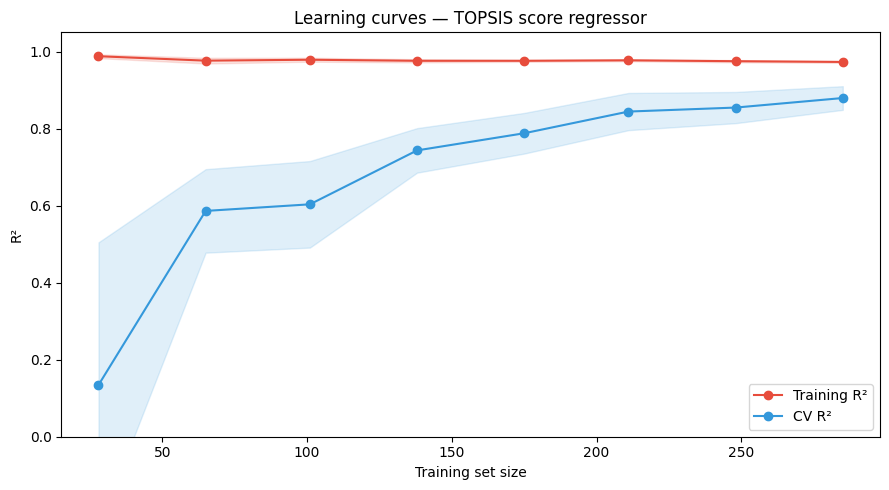

In [20]:
# Learning curve for regressor
train_sizes_r, train_scores_r, cv_scores_r = learning_curve(
    rf_reg, X_reg, y_reg,
    cv=CV_reg,
    scoring="r2",
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=1,
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(train_sizes_r, train_scores_r.mean(axis=1), "o-",
        color="#e74c3c", label="Training R²")
ax.fill_between(train_sizes_r,
                train_scores_r.mean(axis=1) - train_scores_r.std(axis=1),
                train_scores_r.mean(axis=1) + train_scores_r.std(axis=1),
                alpha=0.15, color="#e74c3c")
ax.plot(train_sizes_r, cv_scores_r.mean(axis=1), "o-",
        color="#3498db", label="CV R²")
ax.fill_between(train_sizes_r,
                cv_scores_r.mean(axis=1) - cv_scores_r.std(axis=1),
                cv_scores_r.mean(axis=1) + cv_scores_r.std(axis=1),
                alpha=0.15, color="#3498db")
ax.set_xlabel("Training set size")
ax.set_ylabel("R²")
ax.set_title("Learning curves — TOPSIS score regressor")
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig("A7_learning_curve_reg.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. SHAP — Which Nutrients Drive Nutritional Quality?

Computing SHAP values (TreeExplainer on RF regressor, full-data fit)...


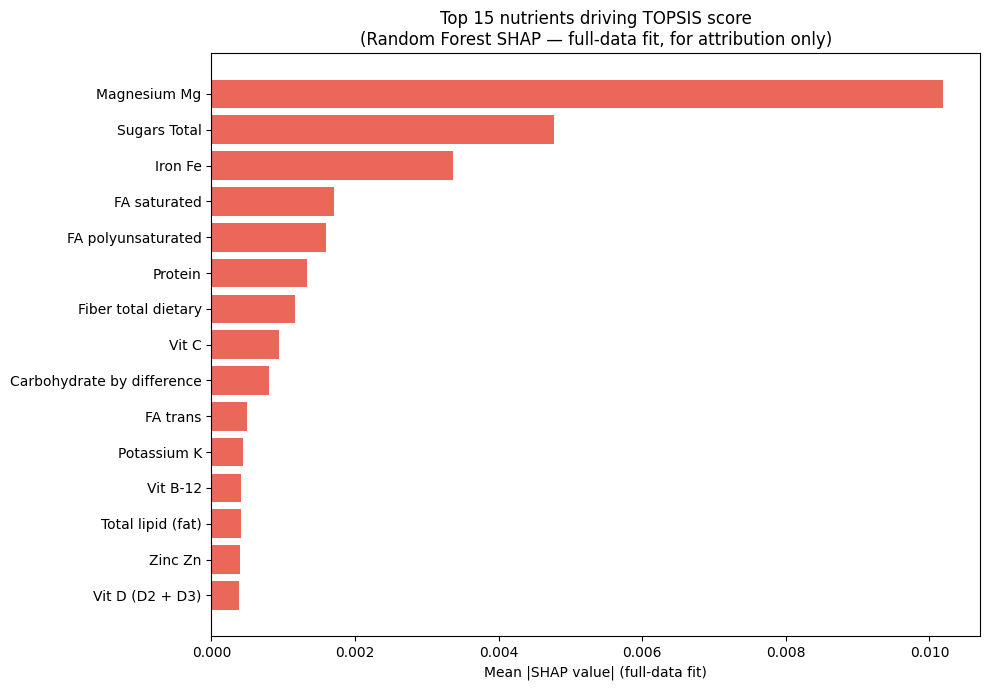


Top 10 nutrients by SHAP importance for TOPSIS:
                   feature  mean_abs_shap
              Magnesium Mg       0.010194
              Sugars Total       0.004776
                   Iron Fe       0.003368
              FA saturated       0.001701
        FA polyunsaturated       0.001594
                   Protein       0.001329
       Fiber total dietary       0.001168
                     Vit C       0.000942
Carbohydrate by difference       0.000802
                  FA trans       0.000488


In [21]:
# Full-data fit for SHAP
rf_reg.fit(X_reg, y_reg)

print("Computing SHAP values (TreeExplainer on RF regressor, full-data fit)...")
explainer_reg   = shap.TreeExplainer(rf_reg)
shap_values_reg = explainer_reg.shap_values(X_reg)

mean_abs_shap_reg = np.abs(shap_values_reg).mean(axis=0)
imp_reg_df = pd.DataFrame({
    "feature":       short_names,
    "mean_abs_shap": mean_abs_shap_reg,
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 7))
top_reg = imp_reg_df.head(15)
ax.barh(top_reg["feature"][::-1], top_reg["mean_abs_shap"][::-1],
        color="#e74c3c", alpha=0.85)
ax.set_xlabel("Mean |SHAP value| (full-data fit)")
ax.set_title("Top 15 nutrients driving TOPSIS score\n"
             "(Random Forest SHAP — full-data fit, for attribution only)")
plt.tight_layout()
plt.savefig("A7_shap_topsis_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nTop 10 nutrients by SHAP importance for TOPSIS:")
print(imp_reg_df.head(10)[["feature", "mean_abs_shap"]].to_string(index=False))

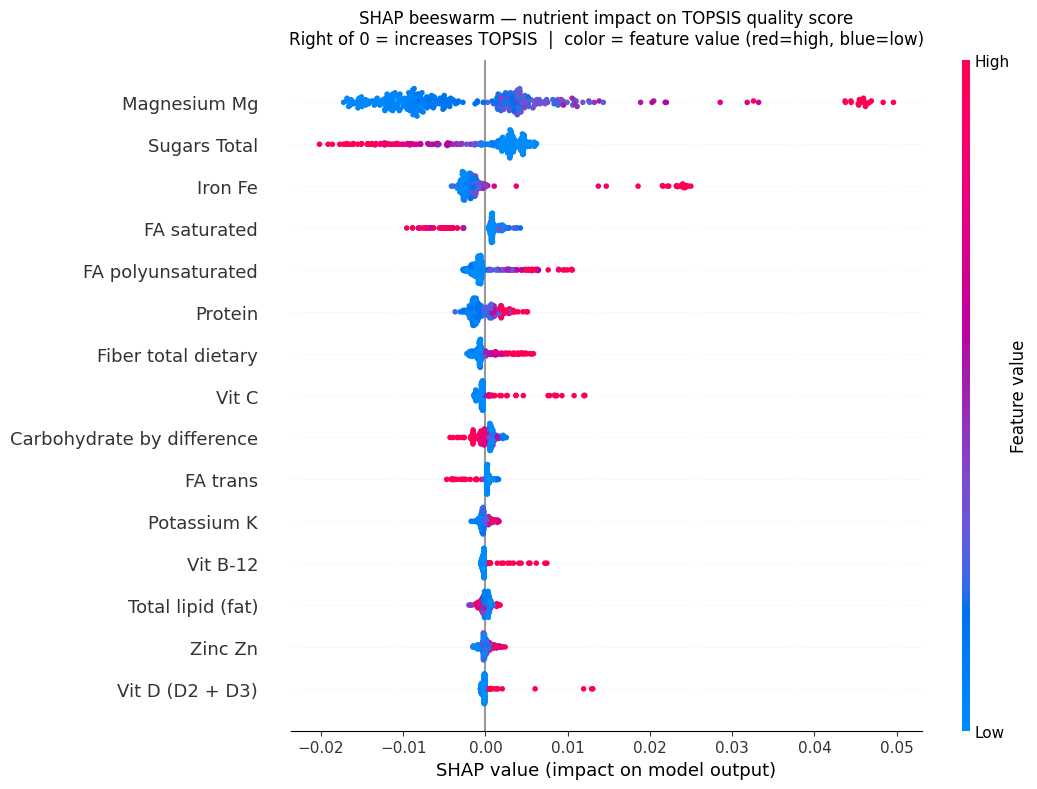

In [22]:
shap.summary_plot(
    shap_values_reg, X_reg,
    feature_names=short_names,
    max_display=15,
    show=False,
    plot_size=(11, 8),
)
plt.title("SHAP beeswarm — nutrient impact on TOPSIS quality score\n"
          "Right of 0 = increases TOPSIS  |  color = feature value (red=high, blue=low)",
          pad=12)
plt.tight_layout()
plt.savefig("A7_shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()

In [23]:
# Cross-comparison: classifier vs regressor SHAP top-10
print("=== SHAP importance: classifier vs regressor ===\n")
print(f"{'Nutrient':35s}  {'Classifier rank':>15s}  {'Regressor rank':>14s}  {'Agree?':>7s}")
print("-" * 76)

clf_rank = {row["feature"]: i + 1 for i, row in importance_df.iterrows()}
reg_rank  = {row["feature"]: i + 1 for i, row in imp_reg_df.iterrows()}
all_feats = list(dict.fromkeys(
    list(importance_df["feature"].head(10)) + list(imp_reg_df["feature"].head(10))
))
for feat in all_feats:
    cr = clf_rank.get(feat, "-")
    rr = reg_rank.get(feat, "-")
    agree = "✓" if isinstance(cr, int) and isinstance(rr, int) and abs(cr - rr) <= 3 else ""
    print(f"{feat:35s}  {str(cr):>15s}  {str(rr):>14s}  {agree:>7s}")
print("\n✓ = within 3 ranks in both models (consistent signal)")

=== SHAP importance: classifier vs regressor ===

Nutrient                             Classifier rank  Regressor rank   Agree?
----------------------------------------------------------------------------
Carbohydrate by difference                         1               9         
Calcium Ca                                         2              18         
Protein                                            3               6        ✓
Potassium K                                        4              11         
Sodium Na                                          5              16         
Cholesterol                                        6              20         
Fiber total dietary                                7               7        ✓
Total lipid (fat)                                  8              13         
Vit C                                              9               8        ✓
Magnesium Mg                                      10               1         
Sugars Total   

## 9. Underrated & Overrated Foods (OOF residuals)

Using OOF residuals — methodologically correct for identifying genuine outliers.

In [24]:
n_show = 10

underrated = df_reg.nlargest(n_show, "topsis_residual_oof")[
    ["description", "group_en", "topsis_score", "topsis_predicted_oof", "topsis_residual_oof"]
]
overrated = df_reg.nsmallest(n_show, "topsis_residual_oof")[
    ["description", "group_en", "topsis_score", "topsis_predicted_oof", "topsis_residual_oof"]
]

print(f"Top {n_show} UNDERRATED (actual TOPSIS >> OOF predicted):")
print(underrated.to_string(index=False))
print(f"\nTop {n_show} OVERRATED (OOF predicted >> actual TOPSIS):")
print(overrated.to_string(index=False))

Top 10 UNDERRATED (actual TOPSIS >> OOF predicted):
                                                      description           group_en  topsis_score  topsis_predicted_oof  topsis_residual_oof
                    Almond milk, unsweetened, plain, shelf stable              dairy      0.507662              0.462744             0.044918
                                                        Kale, raw fruits_veg_legumes      0.523165              0.482811             0.040353
                                     Lettuce, cos or romaine, raw fruits_veg_legumes      0.498426              0.472985             0.025441
                                                  Spinach, mature fruits_veg_legumes      0.526516              0.501759             0.024758
                       Soy milk, unsweetened, plain, shelf stable              dairy      0.466013              0.446121             0.019892
Crustaceans, crab, blue swimming, lump, pasteurized, refrigerated     prepared_meals      0.4711

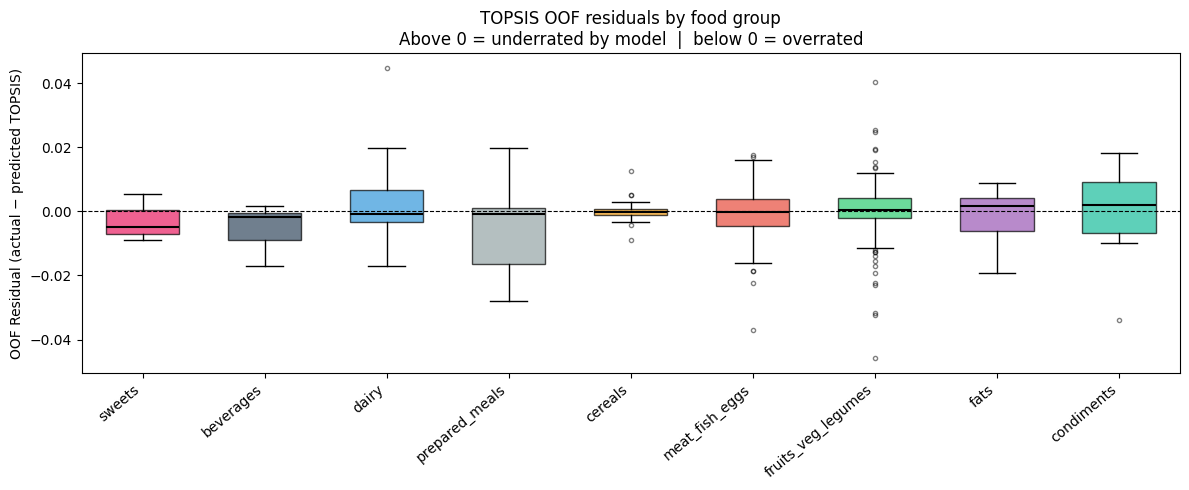

In [25]:
# Residuals by food group
fig, ax = plt.subplots(figsize=(12, 5))
group_order = (df_reg.groupby("group_en")["topsis_residual_oof"]
               .median().sort_values().index.tolist())

for i, grp in enumerate(group_order):
    vals = df_reg.loc[df_reg["group_en"] == grp, "topsis_residual_oof"].dropna()
    ax.boxplot(
        vals, positions=[i], widths=0.6,
        patch_artist=True,
        boxprops=dict(facecolor=PALETTE.get(grp, PALETTE["default"]), alpha=0.7),
        medianprops=dict(color="black", linewidth=1.5),
        flierprops=dict(marker="o", markersize=3, alpha=0.5),
    )

ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xticks(range(len(group_order)))
ax.set_xticklabels(group_order, rotation=40, ha="right")
ax.set_ylabel("OOF Residual (actual − predicted TOPSIS)")
ax.set_title("TOPSIS OOF residuals by food group\n"
             "Above 0 = underrated by model  |  below 0 = overrated")
plt.tight_layout()
plt.savefig("A7_residuals_by_group.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Summary & Key Findings

In [26]:
print("=" * 70)
print("A7 — SUMMARY OF FINDINGS")
print("=" * 70)

top5_clf = "\n".join(f"    {i+1}. {r['feature']}"
                      for i, r in importance_df.head(5).iterrows())
top5_reg = "\n".join(f"    {i+1}. {r['feature']}"
                      for i, r in imp_reg_df.head(5).iterrows())

print(f"""
TRACK D — Food Group Classification (all metrics OOF)
──────────────────────────────────────────────────────
  Baseline macro-F1:            ~{majority_frac / len(valid_groups):.3f}
  Random Forest macro-F1 (CV):   {rf_scores.mean():.3f} ± {rf_scores.std():.3f}
  XGBoost macro-F1 (CV):         {xgb_scores.mean():.3f} ± {xgb_scores.std():.3f}
  Train-CV gap (RF):              {train_mean[-1] - cv_mean[-1]:.3f}

  OOF misclassified: {n_wrong} / {len(df_clf)}  ({100*n_wrong/len(df_clf):.1f}%)
  Hardest group: {conf_series.idxmin()} (mean OOF confidence {conf_series.min():.3f})
  Top confusion pair: {conf_df.iloc[0]['true']} → {conf_df.iloc[0]['predicted']} ({int(conf_df.iloc[0]['count'])} foods)

  Most discriminative nutrients (SHAP top 5):
{top5_clf}

TRACK A — TOPSIS Regression (OOF residuals)
──────────────────────────────────────────────
  R² (CV):  {r2_scores.mean():.3f} ± {r2_scores.std():.3f}
  MAE (CV): {(-mae_scores).mean():.4f}

  Most underrated: {df_reg.nlargest(1,'topsis_residual_oof').iloc[0]['description'][:55]}
  Most overrated:  {df_reg.nsmallest(1,'topsis_residual_oof').iloc[0]['description'][:55]}

  Strongest TOPSIS drivers (SHAP top 5):
{top5_reg}
""")

A7 — SUMMARY OF FINDINGS

TRACK D — Food Group Classification (all metrics OOF)
──────────────────────────────────────────────────────
  Baseline macro-F1:            ~0.077
  Random Forest macro-F1 (CV):   0.786 ± 0.017
  XGBoost macro-F1 (CV):         0.754 ± 0.099
  Train-CV gap (RF):              0.194

  OOF misclassified: 37 / 340  (10.9%)
  Hardest group: condiments (mean OOF confidence 0.189)
  Top confusion pair: condiments → fruits_veg_legumes (6 foods)

  Most discriminative nutrients (SHAP top 5):
    1. Carbohydrate by difference
    2. Calcium Ca
    3. Protein
    4. Potassium K
    5. Sodium Na

TRACK A — TOPSIS Regression (OOF residuals)
──────────────────────────────────────────────
  R² (CV):  0.879 ± 0.031
  MAE (CV): 0.0059

  Most underrated: Almond milk, unsweetened, plain, shelf stable
  Most overrated:  Pickles, cucumber, dill or kosher dill

  Strongest TOPSIS drivers (SHAP top 5):
    1. Magnesium Mg
    2. Sugars Total
    3. Iron Fe
    4. FA saturated
    

## 11. Save

In [27]:
df_clf_out = df_clf[[
    "description", "group_en", "predicted_group_oof",
    "true_group_prob_oof", "predicted_group_prob",
    "correctly_classified", "PCA1_ml", "PCA2_ml",
]].copy()

df_reg_out = df_reg[[
    "description", "group_en", "topsis_score",
    "topsis_predicted_oof", "topsis_residual_oof",
]].copy()

df_out = df_clf_out.merge(df_reg_out, on=["description", "group_en"], how="outer")
df_out.to_csv("foundation_ml_results.csv", index=False)
print("Saved: foundation_ml_results.csv")
print("Shape:", df_out.shape)

print("\nPlots saved:")
for fname in [
    "A7_confusion_matrix_oof.png",
    "A7_learning_curve.png",
    "A7_oof_confidence.png",
    "A7_confusion_hotspots.png",
    "A7_shap_global_importance.png",
    "A7_shap_per_class.png",
    "A7_outliers_pca.png",
    "A7_topsis_regression_oof.png",
    "A7_learning_curve_reg.png",
    "A7_shap_topsis_importance.png",
    "A7_shap_beeswarm.png",
    "A7_residuals_by_group.png",
]:
    print(f"  {fname}")

Saved: foundation_ml_results.csv
Shape: (357, 11)

Plots saved:
  A7_confusion_matrix_oof.png
  A7_learning_curve.png
  A7_oof_confidence.png
  A7_confusion_hotspots.png
  A7_shap_global_importance.png
  A7_shap_per_class.png
  A7_outliers_pca.png
  A7_topsis_regression_oof.png
  A7_learning_curve_reg.png
  A7_shap_topsis_importance.png
  A7_shap_beeswarm.png
  A7_residuals_by_group.png
